# 1. Exploratory Data Analysis

First look at the loan book: what is in it, what is missing, and which variables actually separate defaulters from non-defaulters.

The conclusions here feed directly into `config/model.yaml`.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

DATA = "../data/Loan_Default.csv"

df = pd.read_csv(DATA)
print(df.shape)
df.head(3)

(148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0


## Target

About one loan in four defaults, which is imbalanced but not severely so. It is mild enough that resampling would do more harm than good — it would distort the predicted probabilities, which this project needs to keep meaningful.

In [2]:
counts = df["Status"].value_counts()
print(counts)
print(f"\ndefault rate: {df['Status'].mean():.4f}")

Status
0    112031
1     36639
Name: count, dtype: int64

default rate: 0.2464


## Missing data

Several columns are missing a substantial share of their values. The pattern of what is missing turns out to matter far more than the amount — see notebook 02.

In [3]:
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing[missing > 0].to_frame("percent_missing")

,percent_missing
Upfront_charges,26.66
Interest_rate_spread,24.64
rate_of_interest,24.51
dtir1,16.22
property_value,10.16
LTV,10.16
income,6.15
loan_limit,2.25
approv_in_adv,0.61
age,0.13


## Numeric variables

Note the ranges rather than the averages. LTV reaches 7,831% and income goes to zero, both of which are impossible and are rejected by the data contract in `config/data_contract.yaml`.

In [4]:
df.select_dtypes("number").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.50,42917.48,24890.00,62057.25,99224.50,136391.75,173559.00
year,148670.0,2019.00,0.00,2019.00,2019.00,2019.00,2019.00,2019.00
loan_amount,148670.0,331117.74,183909.31,16500.00,196500.00,296500.00,436500.00,3576500.00
rate_of_interest,112231.0,4.05,0.56,0.00,3.62,3.99,4.38,8.00
Interest_rate_spread,112031.0,0.44,0.51,-3.64,0.08,0.39,0.78,3.36
Upfront_charges,109028.0,3225.00,3251.12,0.00,581.49,2596.45,4812.50,60000.00
term,148629.0,335.14,58.41,96.00,360.00,360.00,360.00,360.00
property_value,133572.0,497893.47,359935.32,8000.00,268000.00,418000.00,628000.00,16508000.00
income,139520.0,6957.34,6496.59,0.00,3720.00,5760.00,8520.00,578580.00
Credit_Score,148670.0,699.79,115.88,500.00,599.00,699.00,800.00,900.00


## Is income monthly or annual?

This matters, because loan-to-income is a headline affordability metric and getting the units wrong makes it meaningless.

In [5]:
d = df.dropna(subset=["income", "loan_amount", "dtir1"])
print(f"median income      {d['income'].median():,.0f}")
print(f"median loan amount {d['loan_amount'].median():,.0f}")
print()
print(f"LTI if income is annual : {(d['loan_amount']/d['income']).median():.1f}x")
print(f"LTI if income is monthly: {(d['loan_amount']/(d['income']*12)).median():.2f}x")
print()
pm = d["loan_amount"] / d["term"]
print(f"implied principal-only burden: {(100*pm/d['income']).median():.1f}% of monthly income")
print(f"reported dtir1               : {d['dtir1'].median():.1f}%")

median income      5,760
median loan amount 296,500

LTI if income is annual : 52.3x
LTI if income is monthly: 4.36x

implied principal-only burden: 15.9% of monthly income
reported dtir1               : 39.0%


A 52x loan-to-income ratio is not a real mortgage; 4.36x is. And a principal-only burden of 15.9% sits sensibly inside a reported total debt-to-income of 39% once interest, taxes and other debt are added.

**Income is monthly.** The feature engineering annualises it.

## Which categorical variables separate the classes?

In [6]:
cats = ["lump_sum_payment", "Neg_ammortization", "business_or_commercial",
        "submission_of_application", "loan_purpose", "occupancy_type",
        "credit_type", "Region"]
for c in cats:
    g = df.groupby(c, observed=True)["Status"].agg(["mean", "size"])
    g.columns = ["default_rate", "n"]
    print(f"--- {c} ---")
    print(g.sort_values("default_rate", ascending=False).round(4).to_string())
    print()

--- lump_sum_payment ---
                  default_rate       n
lump_sum_payment                      
lpsm                    0.7766    3384
not_lpsm                0.2341  145286

--- Neg_ammortization ---
                   default_rate       n
Neg_ammortization                      
neg_amm                  0.4460   15129
not_neg                  0.2238  133420

--- business_or_commercial ---
                        default_rate       n
business_or_commercial                      
b/c                           0.3454   20762
nob/c                         0.2304  127908



--- submission_of_application ---
                           default_rate      n
submission_of_application                     
to_inst                          0.2840  95814
not_inst                         0.1752  52656

--- loan_purpose ---
              default_rate      n
loan_purpose                     
p2                  0.3308   3274
p1                  0.2588  34529
p3                  0.2502  55934
p4                  0.2297  54799

--- occupancy_type ---
                default_rate       n
occupancy_type                      
ir                    0.2999    7340
sr                    0.2713    3129
pr                    0.2430  138201

--- credit_type ---
             default_rate      n
credit_type                     
EQUI               0.9999  15298
CRIF               0.1623  43901
EXP                0.1599  41319
CIB                0.1580  48152

--- Region ---
            default_rate      n
Region                         
North-East        0.3045   1235
central     

Loan *structure* dominates. Balloon repayments default at 66% against a 25% base rate, negative amortisation at 39%, business purpose at 28%. These are the non-traditional mortgage features that drove losses in 2007-08, so the signal is economically sensible rather than an artifact.

## Credit score

The variable you would expect to matter most.

In [7]:
from sklearn.metrics import roc_auc_score
sub = df.dropna(subset=["Credit_Score", "Status"])
auc = roc_auc_score(sub["Status"], sub["Credit_Score"])
print(f"univariate ROC-AUC: {auc:.4f}")
print(f"range: {sub['Credit_Score'].min():.0f} to {sub['Credit_Score'].max():.0f}")
print()
sub = sub.copy()
sub["decile"] = pd.qcut(sub["Credit_Score"], 10, labels=False, duplicates="drop")
print(sub.groupby("decile")["Status"].mean().round(4).to_string())

univariate ROC-AUC: 0.5027
range: 500 to 900

decile
0    0.2462
1    0.2471
2    0.2467
3    0.2427
4    0.2452
5    0.2397
6    0.2459
7    0.2450
8    0.2523
9    0.2538


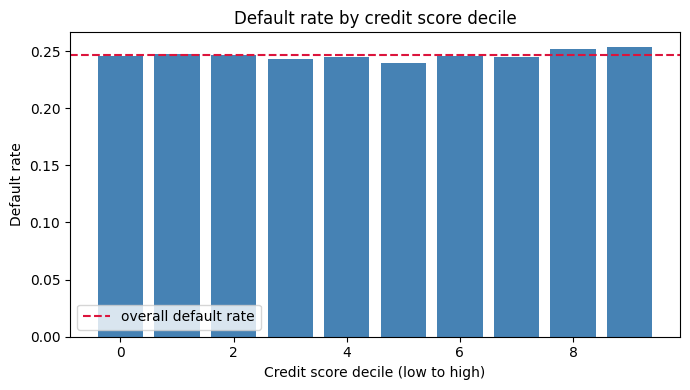

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
rates = sub.groupby("decile")["Status"].mean()
ax.bar(rates.index, rates.values, color="steelblue")
ax.axhline(df["Status"].mean(), color="crimson", ls="--", label="overall default rate")
ax.set_xlabel("Credit score decile (low to high)")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by credit score decile")
ax.legend()
plt.tight_layout()

Completely flat, and an AUC of 0.503 is a coin flip. In real bureau data credit score is the single strongest predictor of default. Its range here (500-900) is also not FICO's (300-850).

**This column appears to be randomly generated.** It is documented as a limitation in `MODEL_CARD.md` and there is a test asserting it stays true, so that if the data ever changes the documentation gets revisited.

## Where this leads

The next notebook deals with the reason an early version of this model scored a perfect 1.0000.